In [1]:
!pip install -U langgraph graphviz langchain langchain-google-genai

In [21]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, END
from IPython.display import Image, display
import graphviz

In [22]:
from google.colab import userdata
GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')

In [23]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash",temperature=0.2,google_api_key=GOOGLE_API_KEY)

In [24]:
from typing import TypedDict

class ChatState(TypedDict):
    message:str
    response:str


In [20]:
def agent_node(state: dict) -> dict:
    """
    Agent checks if it's a currency conversion query.
    If yes, extracts amount/from_cur/to_cur as plain text.
    """
    prompt = ChatPromptTemplate.from_template("""
    The user said: "{question}".

    - If it's a currency conversion, extract:
      - amount (number)
      - from currency (3-letter code)
      - to currency (3-letter code)

    Reply in this format ONLY:
    amount=<number>, from=<FROM>, to=<TO>

    - If it's NOT a conversion, reply:
    no_tool=<your natural response>
    """)
    chain = prompt | llm
    output = chain.invoke({"question": state["message"]}).content.strip()

    if output.startswith("amount="):
        parts = dict(item.split("=") for item in output.split(", "))
        return {
            "message": state["message"],
            "response": "USE_TOOL",
            "amount": float(parts["amount"]),
            "from_cur": parts["from"],
            "to_cur": parts["to"],
        }
    else:
        return {"message": state["message"], "response": output.replace("no_tool=", "").strip()}

In [26]:
import requests
def convert_currency_tool(state: dict) -> dict:
    """Dynamic currency conversion using Frankfurter API."""
    amount = state.get("amount", 1.0)
    from_cur = state.get("from_cur")
    to_cur = state.get("to_cur")

    url = f"https://api.frankfurter.app/latest?amount={amount}&from={from_cur}&to={to_cur}"
    response = requests.get(url)

    if response.status_code == 200:
        data = response.json()
        rate = list(data["rates"].values())[0]
        raw_response = f"{amount} {from_cur} = {rate:.2f} {to_cur}"
    else:
        raw_response = "Error fetching conversion rate."

    return {"message": state["message"], "response": raw_response}

In [27]:
def response_agent_node(state: dict) -> dict:
    """Refines the response from currency_tool into human-readable text."""
    prompt_text = f"""
    Here is a currency conversion result: '{state['response']}'.
    Please convert it into a clear, human-readable sentence.
    """
    refined_response = llm.invoke(prompt_text).content.strip()
    return {"message": state["message"], "response": refined_response}

In [42]:
workflow = StateGraph(dict)

# Add nodes
workflow.add_node("agent", agent_node)
workflow.add_node("convert_currency_tool", convert_currency_tool)
workflow.add_node("response_agent", response_agent_node)


# Conditional routing function
def route_condition(state: dict) -> str:
    if state["response"] == "USE_TOOL":
        return "convert_currency_tool"
    else:
        return END   # <-- use END constant, not "__end__"

# Conditional edges (agent can go either to currency_tool or END)
workflow.add_conditional_edges(
    "agent",
    route_condition,
    {
        "convert_currency_tool": "convert_currency_tool",
        END: END,
    }
)


# Normal edges
workflow.add_edge("convert_currency_tool", "response_agent")
workflow.add_edge("response_agent", END)

workflow.set_entry_point("agent")
app = workflow.compile()

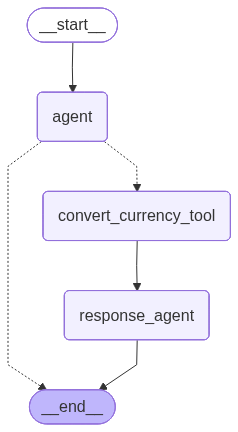

In [43]:
from IPython.display import Image, display
png_bytes = app.get_graph().draw_mermaid_png()
display(Image(data=png_bytes))